# Program-office composition and HEP representation

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "synthetic_perlmutter_memberships_2020_2026.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from artifact_utils import load_memberships, build_user_graph, node_scores, integer_log_bins, assign_bins, office_assignments, category_composition, OFFICE_ORDER, OFFICE_LABELS


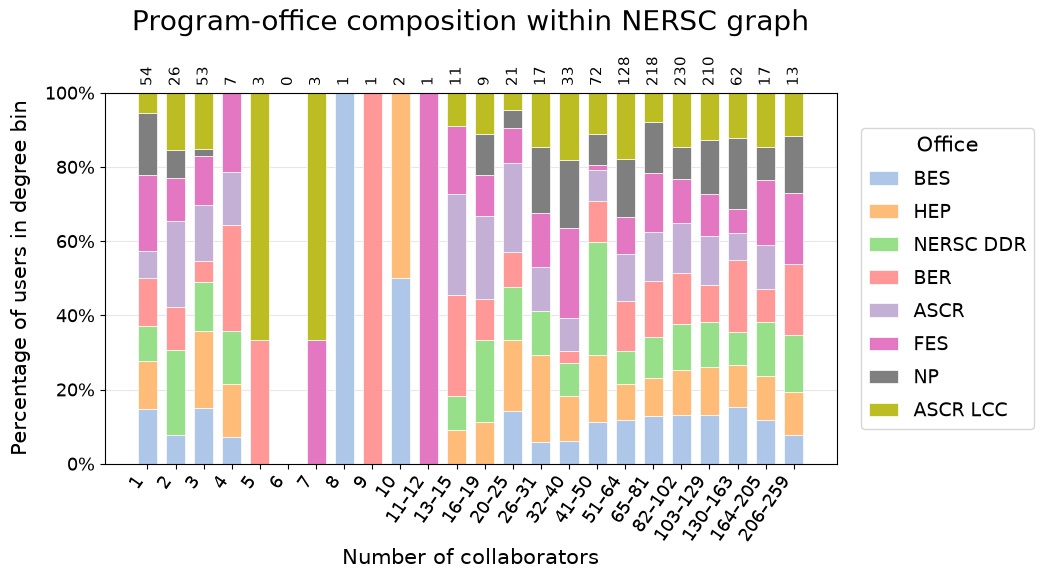

In [2]:
memberships = load_memberships(DATA_PATH)
graph, _ = build_user_graph(memberships)
scores = node_scores(graph).query("degree > 0").reset_index(drop=True)
edges, labels = integer_log_bins(scores["degree"], 24)
binned = assign_bins(scores, "degree", edges, labels)
offices = office_assignments(memberships, binned["user_id"], threshold=1.0)
order = [office for office in OFFICE_ORDER if office in set(offices["office"])]
order += [office for office in ["Other (<1%)", "Unknown"] if office in set(offices["office"])]
bin_counts, composition = category_composition(binned, offices, "office", "weight", order)

pivot = composition.pivot(index="bin_order", columns="office", values="percentage").reindex(columns=order).fillna(0)
x = np.arange(len(bin_counts))
palette_order = OFFICE_ORDER + ["Other (<1%)"]
palette = dict(zip(palette_order, [plt.get_cmap("tab20")(position) for position in np.linspace(0.05, 0.95, 9)]))
colors = [palette.get(office, "0.75") for office in order]
fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(bin_counts))
for office, color in zip(order, colors):
    values = pivot.reindex(x, fill_value=0)[office].to_numpy()
    ax.bar(x, values, bottom=bottom, width=0.68, label=OFFICE_LABELS.get(office, office), color=color, edgecolor="white", linewidth=0.5)
    bottom += values
for position, count in zip(x, bin_counts["n_unique_users"]):
    ax.text(position, 1.018, f"{int(count):,}", transform=ax.get_xaxis_transform(), ha="center", va="bottom", rotation=90, fontsize=11, clip_on=False)
ax.set_title("Program-office composition within NERSC graph", fontsize=20, pad=45)
ax.set_xlabel("Number of collaborators", fontsize=15, labelpad=2)
ax.set_ylabel("Percentage of users in degree bin", fontsize=15, labelpad=10)
ax.set_xticks(x, bin_counts["bin_label"], rotation=55, ha="right", fontsize=13)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis="y", labelsize=13)
ax.grid(axis="y", alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(title="Office", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=14, title_fontsize=15, frameon=True, labelspacing=0.7, handlelength=1.5)
fig.subplots_adjust(left=0.12, right=0.73, top=0.80, bottom=0.27)
fig.savefig(OUTPUT_DIR / "program_office_composition.png", dpi=300, bbox_inches="tight")
plt.show()


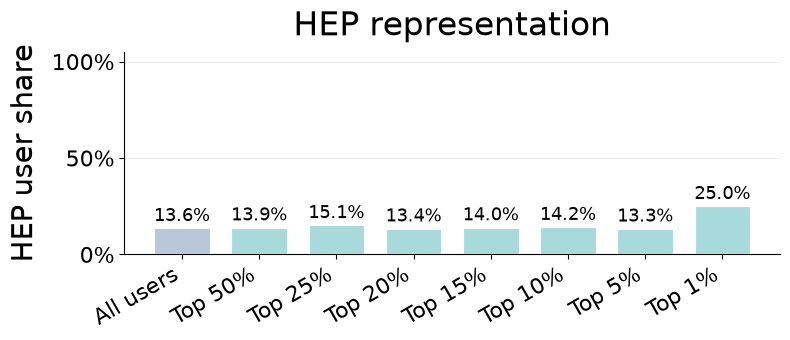

In [3]:
ranked = scores.sort_values(["degree", "user_id"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
hep_users = set(memberships.loc[memberships["office"].eq("High Energy Physics"), "user_id"])
thresholds = [100, 50, 25, 20, 15, 10, 5, 1]
rows = []
for percent in thresholds:
    size = min(len(ranked), max(1, int(np.ceil(len(ranked) * percent / 100))))
    rows.append((percent, 100.0 * ranked.head(size)["user_id"].isin(hep_users).sum() / size))
hep = pd.DataFrame(rows, columns=["percent", "share"])
hep["label"] = hep["percent"].map(lambda value: "All users" if value == 100 else f"Top {value}%")

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(hep))
bars = ax.bar(x, hep["share"], width=0.72, color=["#B8C7D9"] + ["#A8DADC"] * (len(hep) - 1), edgecolor="white", linewidth=0.8, zorder=3)
for bar, value in zip(bars, hep["share"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=13)
ax.set_title("HEP representation", fontsize=24, pad=12)
ax.set_ylabel("HEP user share", fontsize=21, labelpad=9)
ax.set_xticks(x, hep["label"], rotation=30, ha="right", fontsize=16)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis="y", labelsize=16)
ax.grid(axis="y", alpha=0.22, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hep_representation.png", dpi=300, bbox_inches="tight")
plt.show()
